# Analysis of Shoe Sales and Article Data

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

## Load Data
Loading cleaning data from `clean_sales.csv` and `clean_articles.csv`.

In [111]:
# Load cleaned data
df_sales = pd.read_csv('clean_sales2.csv')
df_articles = pd.read_csv('clean_articles2.csv')

print("Sales Data loaded successfully.")
print("Articles Data loaded successfully.")

Sales Data loaded successfully.
Articles Data loaded successfully.


## Data Inspection

In [112]:
print("--- Sales Data Info ---")
print(df_sales.info())
display(df_sales.head())

print("\n--- Articles Data Info ---")
print(df_articles.info())
display(df_articles.head())

--- Sales Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Article            310 non-null    object 
 1   Shop               310 non-null    object 
 2   Consegnato_Qty     310 non-null    float64
 3   Venduto_Qty        310 non-null    float64
 4   Periodo_Qty        310 non-null    float64
 5   Altro_Venduto_Qty  310 non-null    float64
 6   Giacenza_Qty       310 non-null    float64
 7   Sellout_Percent    310 non-null    float64
 8   Valore_1           310 non-null    float64
 9   Valore_2           310 non-null    float64
 10  Valore_3           310 non-null    float64
 11  Valore_4           310 non-null    float64
dtypes: float64(10), object(2)
memory usage: 29.2+ KB
None


,Article,Shop,Consegnato_Qty,Venduto_Qty,Periodo_Qty,Altro_Venduto_Qty,Giacenza_Qty,Sellout_Percent,Valore_1,Valore_2,Valore_3,Valore_4
0,68/1250CTM,AR,8.00,1.00,1.00,7.00,12.50,240.00,89.34,89.34,210.00,0.00
1,68/1250CTM,AU,8.00,0.00,0.00,8.00,0.00,240.00,0.00,0.00,240.00,0.00
2,68/1250CTM,BO,8.00,1.00,1.00,7.00,12.50,240.00,89.34,89.34,210.00,0.00
3,68/1250CTM,BS,8.00,0.00,0.00,8.00,0.00,240.00,0.00,0.00,240.00,0.00
4,68/1250CTM,CA,8.00,0.00,0.00,8.00,0.00,240.00,0.00,0.00,240.00,0.00



--- Articles Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Article          324 non-null    object 
 1   Description      324 non-null    object 
 2   Shop             324 non-null    object 
 3   Ricevuto         324 non-null    int64  
 4   Giacenza         324 non-null    float64
 5   Consegnato       324 non-null    float64
 6   Venduto          324 non-null    float64
 7   Sellout_Percent  324 non-null    float64
 8   Size_35          324 non-null    float64
 9   Size_36          324 non-null    float64
 10  Size_37          324 non-null    float64
 11  Size_38          324 non-null    float64
 12  Size_39          324 non-null    float64
 13  Size_40          324 non-null    float64
 14  Size_41          324 non-null    float64
 15  Size_42          324 non-null    float64
 16  Valore_Giac      324 non-null    f

,Article,Description,Shop,Ricevuto,Giacenza,Consegnato,Venduto,Sellout_Percent,Size_35,Size_36,Size_37,Size_38,Size_39,Size_40,Size_41,Size_42,Valore_Giac
0,68/1250CTM,T10 LACE BARCA NAPP ACC,AU,0,8.00,8.00,0.00,0.00,0.00,0.00,1.00,2.00,2.00,2.00,1.00,0.00,240.00
1,68/1250CTM,T10 LACE BARCA NAPP ACC,BO,0,7.00,8.00,1.00,0.41,0.00,1.00,2.00,2.00,1.00,1.00,0.00,0.00,210.00
2,68/1250CTM,T10 LACE BARCA NAPP ACC,BS,0,8.00,8.00,0.00,0.00,0.00,0.00,1.00,2.00,2.00,2.00,1.00,0.00,240.00
3,68/1250CTM,T10 LACE BARCA NAPP ACC,CA,0,8.00,8.00,0.00,0.00,0.00,0.00,1.00,2.00,2.00,2.00,1.00,0.00,240.00
4,68/1250CTM,T10 LACE BARCA NAPP ACC,CO,0,8.00,8.00,0.00,0.00,0.00,1.00,2.00,2.00,2.00,1.00,0.00,0.00,240.00


## Sales Analysis
Analyzing sales performance by Shop and Article.

C:\Users\eris\AppData\Local\Temp\ipykernel_28924\2990842126.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_shops.values, y=top_shops.index, palette='viridis')


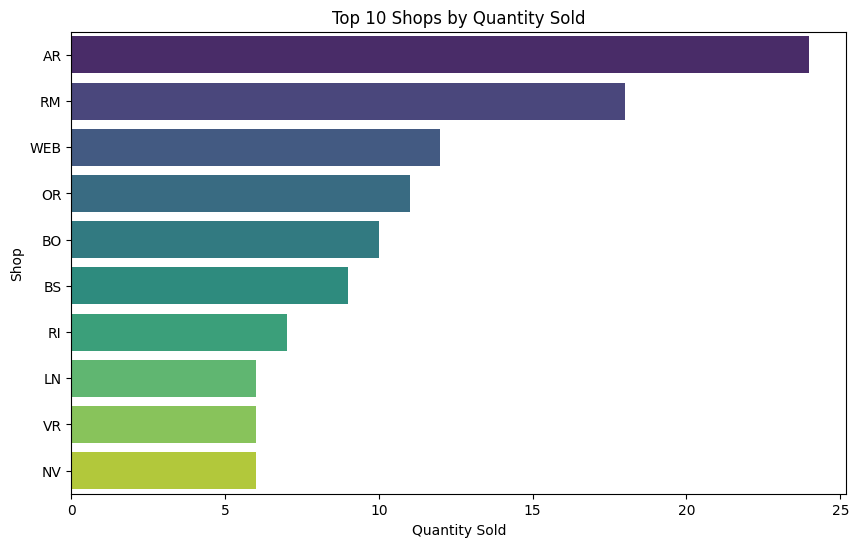

C:\Users\eris\AppData\Local\Temp\ipykernel_28924\2990842126.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_articles.values, y=top_articles.index, palette='magma')


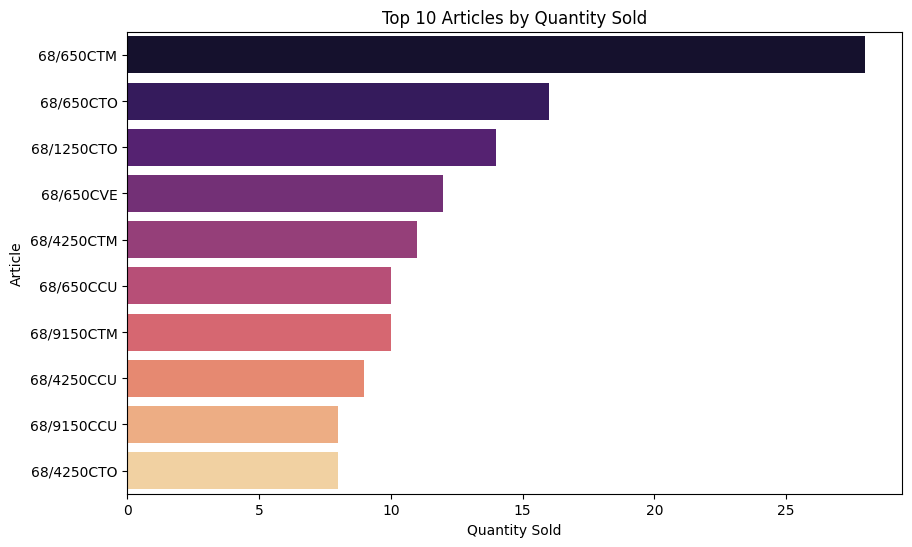

In [113]:
# Top 10 Shops by Quantity Sold
top_shops = df_sales.groupby('Shop')['Venduto_Qty'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_shops.values, y=top_shops.index, palette='viridis')
plt.title('Top 10 Shops by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Shop')
plt.show()

# Top 10 Articles by Quantity Sold
top_articles = df_sales.groupby('Article')['Venduto_Qty'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_articles.values, y=top_articles.index, palette='magma')
plt.title('Top 10 Articles by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Article')
plt.show()

## Inventory Analysis
Analyzing stock levels.

C:\Users\eris\AppData\Local\Temp\ipykernel_28924\3048263359.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stock_by_shop.index, y=stock_by_shop.values, palette='coolwarm')


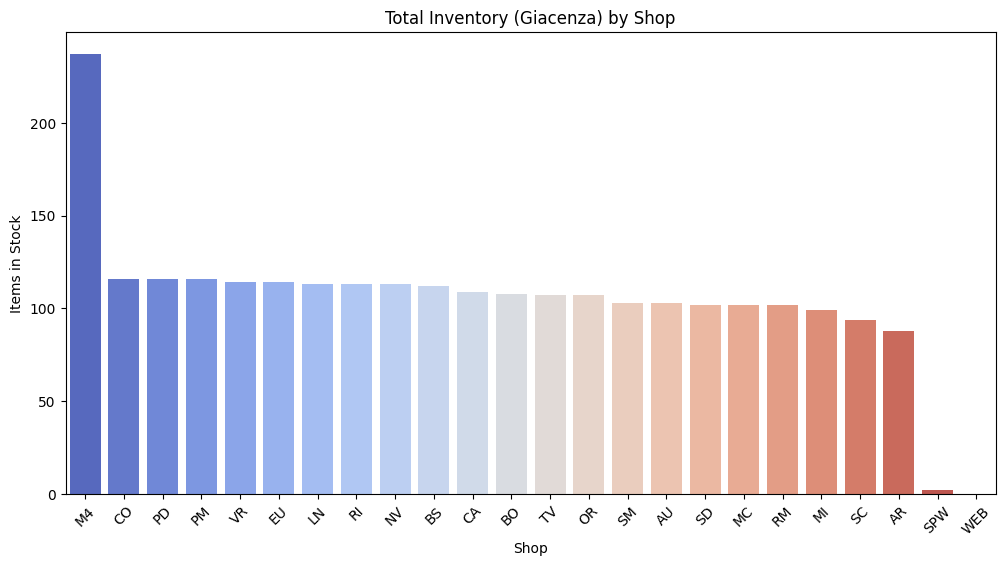

In [114]:
# Total Inventory by Shop
stock_by_shop = df_articles.groupby('Shop')['Giacenza'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=stock_by_shop.index, y=stock_by_shop.values, palette='coolwarm')
plt.title('Total Inventory (Giacenza) by Shop')
plt.xticks(rotation=45)
plt.ylabel('Items in Stock')
plt.show()

In [115]:
df_articles.describe()

,Ricevuto,Giacenza,Consegnato,Venduto,Sellout_Percent,Size_35,Size_36,Size_37,Size_38,Size_39,Size_40,Size_41,Size_42,Valore_Giac
count,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00
mean,0.00,7.69,8.14,0.45,0.24,0.00,0.43,1.39,1.94,1.91,1.49,0.53,0.00,231.13
std,0.00,5.77,5.76,0.86,0.44,0.00,0.50,0.85,1.54,1.47,1.55,0.88,0.00,161.70
min,0.00,0.00,0.00,-2.00,-0.83,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,7.00,8.00,0.00,0.00,0.00,0.00,1.00,2.00,2.00,1.00,0.00,0.00,195.00
50%,0.00,8.00,8.00,0.00,0.00,0.00,0.00,1.00,2.00,2.00,1.00,0.00,0.00,224.00
75%,0.00,8.00,8.00,1.00,0.42,0.00,1.00,2.00,2.00,2.00,2.00,1.00,0.00,256.00
max,0.00,57.00,57.00,6.00,2.70,0.00,1.00,7.00,15.00,14.00,14.00,7.00,0.00,1710.00


In [116]:
df_articles = df_articles.drop(['Ricevuto', 'Valore_Giac', 'Sellout_Percent'], axis=1)

In [117]:
df_articles = df_articles.merge(df_sales[['Article', 'Shop', 'Periodo_Qty']], on=['Article', 'Shop'], how='left')



In [118]:
df_articles

,Article,Description,Shop,Giacenza,Consegnato,Venduto,Size_35,Size_36,Size_37,Size_38,Size_39,Size_40,Size_41,Size_42,Periodo_Qty
0,68/1250CTM,T10 LACE BARCA NAPP ACC,AU,8.00,8.00,0.00,0.00,0.00,1.00,2.00,2.00,2.00,1.00,0.00,0.00
1,68/1250CTM,T10 LACE BARCA NAPP ACC,BO,7.00,8.00,1.00,0.00,1.00,2.00,2.00,1.00,1.00,0.00,0.00,1.00
2,68/1250CTM,T10 LACE BARCA NAPP ACC,BS,8.00,8.00,0.00,0.00,0.00,1.00,2.00,2.00,2.00,1.00,0.00,0.00
3,68/1250CTM,T10 LACE BARCA NAPP ACC,CA,8.00,8.00,0.00,0.00,0.00,1.00,2.00,2.00,2.00,1.00,0.00,0.00
4,68/1250CTM,T10 LACE BARCA NAPP ACC,CO,8.00,8.00,0.00,0.00,1.00,2.00,2.00,2.00,1.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,68/9150CTO,T10 LACE BARCA ACC PERL FRANGE,SC,8.00,8.00,0.00,0.00,1.00,2.00,2.00,2.00,1.00,0.00,0.00,0.00
320,68/9150CTO,T10 LACE BARCA ACC PERL FRANGE,SD,7.00,8.00,1.00,0.00,1.00,2.00,1.00,2.00,1.00,0.00,0.00,1.00
321,68/9150CTO,T10 LACE BARCA ACC PERL FRANGE,SM,8.00,8.00,0.00,0.00,0.00,1.00,2.00,2.00,2.00,1.00,0.00,0.00
322,68/9150CTO,T10 LACE BARCA ACC PERL FRANGE,TV,8.00,8.00,0.00,0.00,0.00,1.00,2.00,2.00,2.00,1.00,0.00,0.00


In [119]:
# Assuming 'df' is the main DataFrame
most_sold_articles = df_sales.groupby('Article')['Venduto_Qty'].sum().sort_values(ascending=False)
most_sold_articles.head(10)


Article
68/650CTM    28.00
68/650CTO    16.00
68/1250CTO   14.00
68/650CVE    12.00
68/4250CTM   11.00
68/650CCU    10.00
68/9150CTM   10.00
68/4250CCU    9.00
68/9150CCU    8.00
68/4250CTO    8.00
Name: Venduto_Qty, dtype: float64

In [120]:
target_article = '68/650CTM'
#target_article = '59/5031CTM'

In [121]:

stock_situation = df_articles[df_articles['Article'] == target_article].copy()
stock_situation.loc['Total'] = stock_situation.sum(numeric_only=True)
stock_situation.at['Total', 'Article'] = 'Total'
stock_situation



,Article,Description,Shop,Giacenza,Consegnato,Venduto,Size_35,Size_36,Size_37,Size_38,Size_39,Size_40,Size_41,Size_42,Periodo_Qty
165,68/650CTM,T10 LACE BARCA NAPPINE,AR,5.00,8.00,3.00,0.00,0.00,1.00,1.00,2.00,0.00,1.00,0.00,3.00
166,68/650CTM,T10 LACE BARCA NAPPINE,AU,8.00,8.00,0.00,0.00,1.00,2.00,2.00,2.00,1.00,0.00,0.00,0.00
167,68/650CTM,T10 LACE BARCA NAPPINE,BO,4.00,8.00,3.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,0.00,2.00
168,68/650CTM,T10 LACE BARCA NAPPINE,BS,8.00,8.00,0.00,0.00,1.00,2.00,2.00,2.00,1.00,0.00,0.00,0.00
169,68/650CTM,T10 LACE BARCA NAPPINE,CA,8.00,8.00,0.00,0.00,1.00,2.00,2.00,2.00,1.00,0.00,0.00,0.00
170,68/650CTM,T10 LACE BARCA NAPPINE,CO,7.00,8.00,2.00,0.00,0.00,1.00,2.00,1.00,2.00,1.00,0.00,2.00
171,68/650CTM,T10 LACE BARCA NAPPINE,EU,7.00,8.00,1.00,0.00,0.00,1.00,2.00,2.00,1.00,1.00,0.00,1.00
172,68/650CTM,T10 LACE BARCA NAPPINE,LN,6.00,8.00,2.00,0.00,1.00,1.00,1.00,2.00,1.00,0.00,0.00,2.00
173,68/650CTM,T10 LACE BARCA NAPPINE,M4,56.00,57.00,0.00,0.00,0.00,6.00,15.00,14.00,14.00,7.00,0.00,NaN
174,68/650CTM,T10 LACE BARCA NAPPINE,MC,8.00,8.00,0.00,0.00,0.00,1.00,2.00,2.00,2.00,1.00,0.00,0.00


In [103]:

# Assuming size columns are those between the first size and the last size, or specific ones.
# We'll identify size columns by excluding metadata and calculated columns.
metadata_cols = ['Article', 'Description', 'Shop', 'Giacenza', 'Venduto', 'Consegnato', 'Periodo_Qty']
size_cols = [c for c in stock_situation.columns if c not in metadata_cols]

# Check 1: Sum of size stocks equals Giacenze
print(stock_situation[stock_situation['Article']=='Total'][size_cols].sum(axis=1))

# Check 2: Giacenze + Venduto equals Consegnato
print(stock_situation[stock_situation['Article']=='Total']['Giacenza'] + stock_situation[stock_situation['Article']=='Total']['Venduto'])


Total   191.00
dtype: float64
Total   216.00
dtype: float64


In [122]:
df_sales[df_sales['Article']==target_article]

,Article,Shop,Consegnato_Qty,Venduto_Qty,Periodo_Qty,Altro_Venduto_Qty,Giacenza_Qty,Sellout_Percent,Valore_1,Valore_2,Valore_3,Valore_4
158,68/650CTM,AR,8.00,3.00,3.00,5.00,37.50,220.00,268.03,268.03,137.50,0.00
159,68/650CTM,AU,8.00,0.00,0.00,8.00,0.00,220.00,0.00,0.00,220.00,0.00
160,68/650CTM,BO,8.00,3.00,2.00,4.00,37.50,220.00,268.03,178.69,110.00,0.00
161,68/650CTM,BS,8.00,0.00,0.00,8.00,0.00,220.00,0.00,0.00,220.00,0.00
162,68/650CTM,CA,8.00,0.00,0.00,8.00,0.00,220.00,0.00,0.00,220.00,0.00
163,68/650CTM,CO,8.00,2.00,2.00,7.00,25.00,220.00,178.69,178.69,192.50,0.00
164,68/650CTM,EU,8.00,1.00,1.00,7.00,12.50,220.00,89.34,89.34,192.50,0.00
165,68/650CTM,LN,8.00,2.00,2.00,6.00,25.00,220.00,178.69,178.69,165.00,0.00
166,68/650CTM,MC,8.00,0.00,0.00,8.00,0.00,220.00,0.00,0.00,220.00,0.00
167,68/650CTM,MI,8.00,1.00,1.00,7.00,12.50,220.00,89.34,89.34,192.50,0.00


In [108]:
def suggest_transfers(df_articles, article_name):
    # 1. Filtriamo per l'articolo selezionato
    df_art = df_articles[df_articles['Article'] == article_name].copy()
    
    if df_art.empty:
        return "Articolo non trovato."

    # Definizione delle colonne taglie
    size_cols = ['Size_35', 'Size_36', 'Size_37', 'Size_38', 'Size_39', 'Size_40', 'Size_41', 'Size_42']
    
    # 2. Identifichiamo i Negozi "Destinazione" (chi ha venduto recentemente e ha poco stock)
    # Criterio: Ha venduto nel periodo e ha una giacenza totale bassa (< 2 paia o simile)
    destinazioni = df_art[
        (df_art['Venduto'] > 0) & (df_art['Shop'] != 'WEB') &
        (df_art['Giacenza'] <= 6) # Soglia modificabile
    ].sort_values(by='Venduto', ascending=False)

    # 3. Identifichiamo i Negozi "Sorgente" (chi ha l'articolo fermo)
    # Criterio: Ha giacenza ma NON ha venduto nulla nel periodo
    sorgenti = df_art[
        (df_art['Venduto'] == 0) & (df_art['Shop'] != 'WEB') &
        (df_art['Giacenza'] > 0)
    ].sort_values(by='Giacenza', ascending=False)

    trasferimenti_suggeriti = []

    # 4. Logica di Matching Taglie
    # Cicliamo sulle destinazioni per cercare di "riempire i buchi"
    for _, dest in destinazioni.iterrows():
        # Vediamo quali taglie mancano nel negozio destinazione (Giacenza taglia == 0)
        taglie_mancanti = [s for s in size_cols if dest[s] == 0]
        
        for taglia in taglie_mancanti:
            # Cerchiamo se qualcuno dei negozi sorgente ha quella taglia
            for idx_sorgente, sorg in sorgenti.iterrows():
                if sorg[taglia] > 0:
                    # Abbiamo trovato un match!
                    trasferimenti_suggeriti.append({
                        'Articolo': article_name,
                        'Da_Negozio': sorg['Shop'],
                        'A_Negozio': dest['Shop'],
                        'Taglia': taglia.replace('Size_', ''),
                        'Motivo': f"Vendite Recenti: {dest['Periodo_Qty']} | Stock Fermo a {sorg['Shop']}"
                    })
                    
                    # Aggiorniamo temporaneamente i dati per evitare doppi trasferimenti della stessa scarpa
                    sorgenti.at[idx_sorgente, taglia] -= 1
                    sorgenti.at[idx_sorgente, 'Giacenza'] -= 1
                    break # Passa alla prossima taglia mancante per questa destinazione
    
    return pd.DataFrame(trasferimenti_suggeriti)



In [106]:
tutti_articoli = list(set(df_articles['Article']))

In [56]:
tutti_articoli

['68/100CTO']

In [123]:
# --- ESEMPIO DI UTILIZZO ---
# supponendo che il tuo dataframe si chiami df_articles
suggerimenti = suggest_transfers(df_articles, target_article)
print(suggerimenti)

     Articolo Da_Negozio A_Negozio Taglia                                   Motivo
0   68/650CTM         AU        RM     36  Vendite Recenti: 6.0 | Stock Fermo a AU
1   68/650CTM         M4        RM     38  Vendite Recenti: 6.0 | Stock Fermo a M4
2   68/650CTM         M4        RM     39  Vendite Recenti: 6.0 | Stock Fermo a M4
3   68/650CTM         M4        RM     40  Vendite Recenti: 6.0 | Stock Fermo a M4
4   68/650CTM         M4        RM     41  Vendite Recenti: 6.0 | Stock Fermo a M4
5   68/650CTM         BS        AR     36  Vendite Recenti: 3.0 | Stock Fermo a BS
6   68/650CTM         M4        AR     40  Vendite Recenti: 3.0 | Stock Fermo a M4
7   68/650CTM         CA        BO     36  Vendite Recenti: 2.0 | Stock Fermo a CA
8   68/650CTM         M4        BO     37  Vendite Recenti: 2.0 | Stock Fermo a M4
9   68/650CTM         SD        TV     36  Vendite Recenti: 3.0 | Stock Fermo a SD
10  68/650CTM         M4        NV     41  Vendite Recenti: 1.0 | Stock Fermo a M4
11  

In [76]:
for art in tutti_articoli:
    print(art, suggest_transfers(df_articles, art))


68/100CTO      Articolo Da_Negozio A_Negozio Taglia                                   Motivo
0   68/100CTO         BO        BS     36  Vendite Recenti: nan | Stock Fermo a BO
1   68/100CTO         BO        BS     39  Vendite Recenti: nan | Stock Fermo a BO
2   68/100CTO         BO        BS     40  Vendite Recenti: nan | Stock Fermo a BO
3   68/100CTO         BO        PD     38  Vendite Recenti: nan | Stock Fermo a BO
4   68/100CTO         BO        PD     39  Vendite Recenti: nan | Stock Fermo a BO
5   68/100CTO         CO        MI     36  Vendite Recenti: nan | Stock Fermo a CO
6   68/100CTO         BO        MI     38  Vendite Recenti: nan | Stock Fermo a BO
7   68/100CTO         CO        MI     40  Vendite Recenti: nan | Stock Fermo a CO
8   68/100CTO         SM        AU     36  Vendite Recenti: nan | Stock Fermo a SM
9   68/100CTO         BO        AU     37  Vendite Recenti: nan | Stock Fermo a BO
10  68/100CTO         CO        AU     39  Vendite Recenti: nan | Stock Fermo